# C. elegans 3D Nuclei Instance Segmentation Dataset

**Source:** [Zenodo 5942575](https://zenodo.org/records/5942575)

28 confocal microscopy volumes of *C. elegans* at L1 stage with dense nuclei instance
segmentation masks (~540 nuclei per worm). Originally from Long et al. (2009) *Nature Methods*,
masks curated by Dagmar Kainmueller (MDC Berlin), train/val/test split from
Weigert et al. (2020) StarDist 3D.

- **Resolution:** 0.116 x 0.116 x 0.122 µm/px (nearly isotropic)
- **Volumes:** ~140 x 140 x 1050 px (YXZ), uint8 images, uint32 instance masks
- **Split:** 18 train / 3 val / 7 test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import tifffile
from skimage.segmentation import find_boundaries
from skimage.measure import regionprops

DATA_DIR = Path("../data/c_elegans/c_elegans_nuclei")
PIXEL_SIZE = (0.116, 0.116, 0.122)  # Y, X, Z in µm

## 1. Dataset overview

In [2]:
# Catalog all volumes
catalog = []
for split in ["train", "val", "test"]:
    for img_path in sorted((DATA_DIR / split / "images").glob("*.tif")):
        mask_path = DATA_DIR / split / "masks" / img_path.name
        img = tifffile.imread(str(img_path))
        mask = tifffile.imread(str(mask_path))
        n_nuclei = len(np.unique(mask)) - 1
        catalog.append({
            "split": split, "name": img_path.stem,
            "shape": img.shape, "n_nuclei": n_nuclei,
            "img": img, "mask": mask,
        })

print(f"Total volumes: {len(catalog)}")
for split in ["train", "val", "test"]:
    subset = [c for c in catalog if c['split'] == split]
    nuclei = [c['n_nuclei'] for c in subset]
    print(f"  {split:>5s}: {len(subset):>2d} volumes, "
          f"{np.mean(nuclei):.0f} ± {np.std(nuclei):.0f} nuclei/volume")

Total volumes: 28
  train: 18 volumes, 544 ± 12 nuclei/volume
    val:  3 volumes, 533 ± 5 nuclei/volume
   test:  7 volumes, 537 ± 8 nuclei/volume


In [3]:
# Volume dimensions summary
print(f"{'Name':<35s} {'Split':>5s} {'Shape (Y,X,Z)':>20s} {'Nuclei':>7s}")
print("-" * 70)
for c in catalog:
    print(f"{c['name']:<35s} {c['split']:>5s} {str(c['shape']):>20s} {c['n_nuclei']:>7d}")

Name                                Split        Shape (Y,X,Z)  Nuclei
----------------------------------------------------------------------
C18G1_2L1_1                         train     (140, 140, 1244)     555
cnd1threeL1_1213061                 train     (140, 140, 1213)     555
cnd1threeL1_1228061                 train     (140, 140, 1137)     566
cnd1threeL1_1229062                 train     (140, 140, 1221)     542
cnd1threeL1_1229063                 train     (140, 140, 1184)     544
eft3RW10035L1_0125073               train     (140, 140, 1094)     544
egl5L1_0606074                      train     (140, 140, 1166)     550
elt3L1_0503072                      train     (140, 140, 1237)     556
elt3L1_0504073                      train     (140, 140, 1140)     536
hlh1fourL1_0417071                  train     (140, 140, 1275)     512
hlh1fourL1_0417076                  train     (140, 140, 1255)     534
hlh1fourL1_0417077                  train     (140, 140, 1274)     545
hlh1fo

## 2. Visualize one volume — orthogonal views

In [4]:
# Pick a representative volume
ex = catalog[0]
img = ex["img"]
mask = ex["mask"]
name = ex["name"]
ny, nx, nz = img.shape

print(f"Volume: {name}")
print(f"Shape (Y, X, Z): {img.shape}")
print(f"Physical size: {ny*0.116:.1f} x {nx*0.116:.1f} x {nz*0.122:.1f} µm")
print(f"Nuclei: {ex['n_nuclei']}")

Volume: C18G1_2L1_1
Shape (Y, X, Z): (140, 140, 1244)
Physical size: 16.2 x 16.2 x 151.8 µm
Nuclei: 555


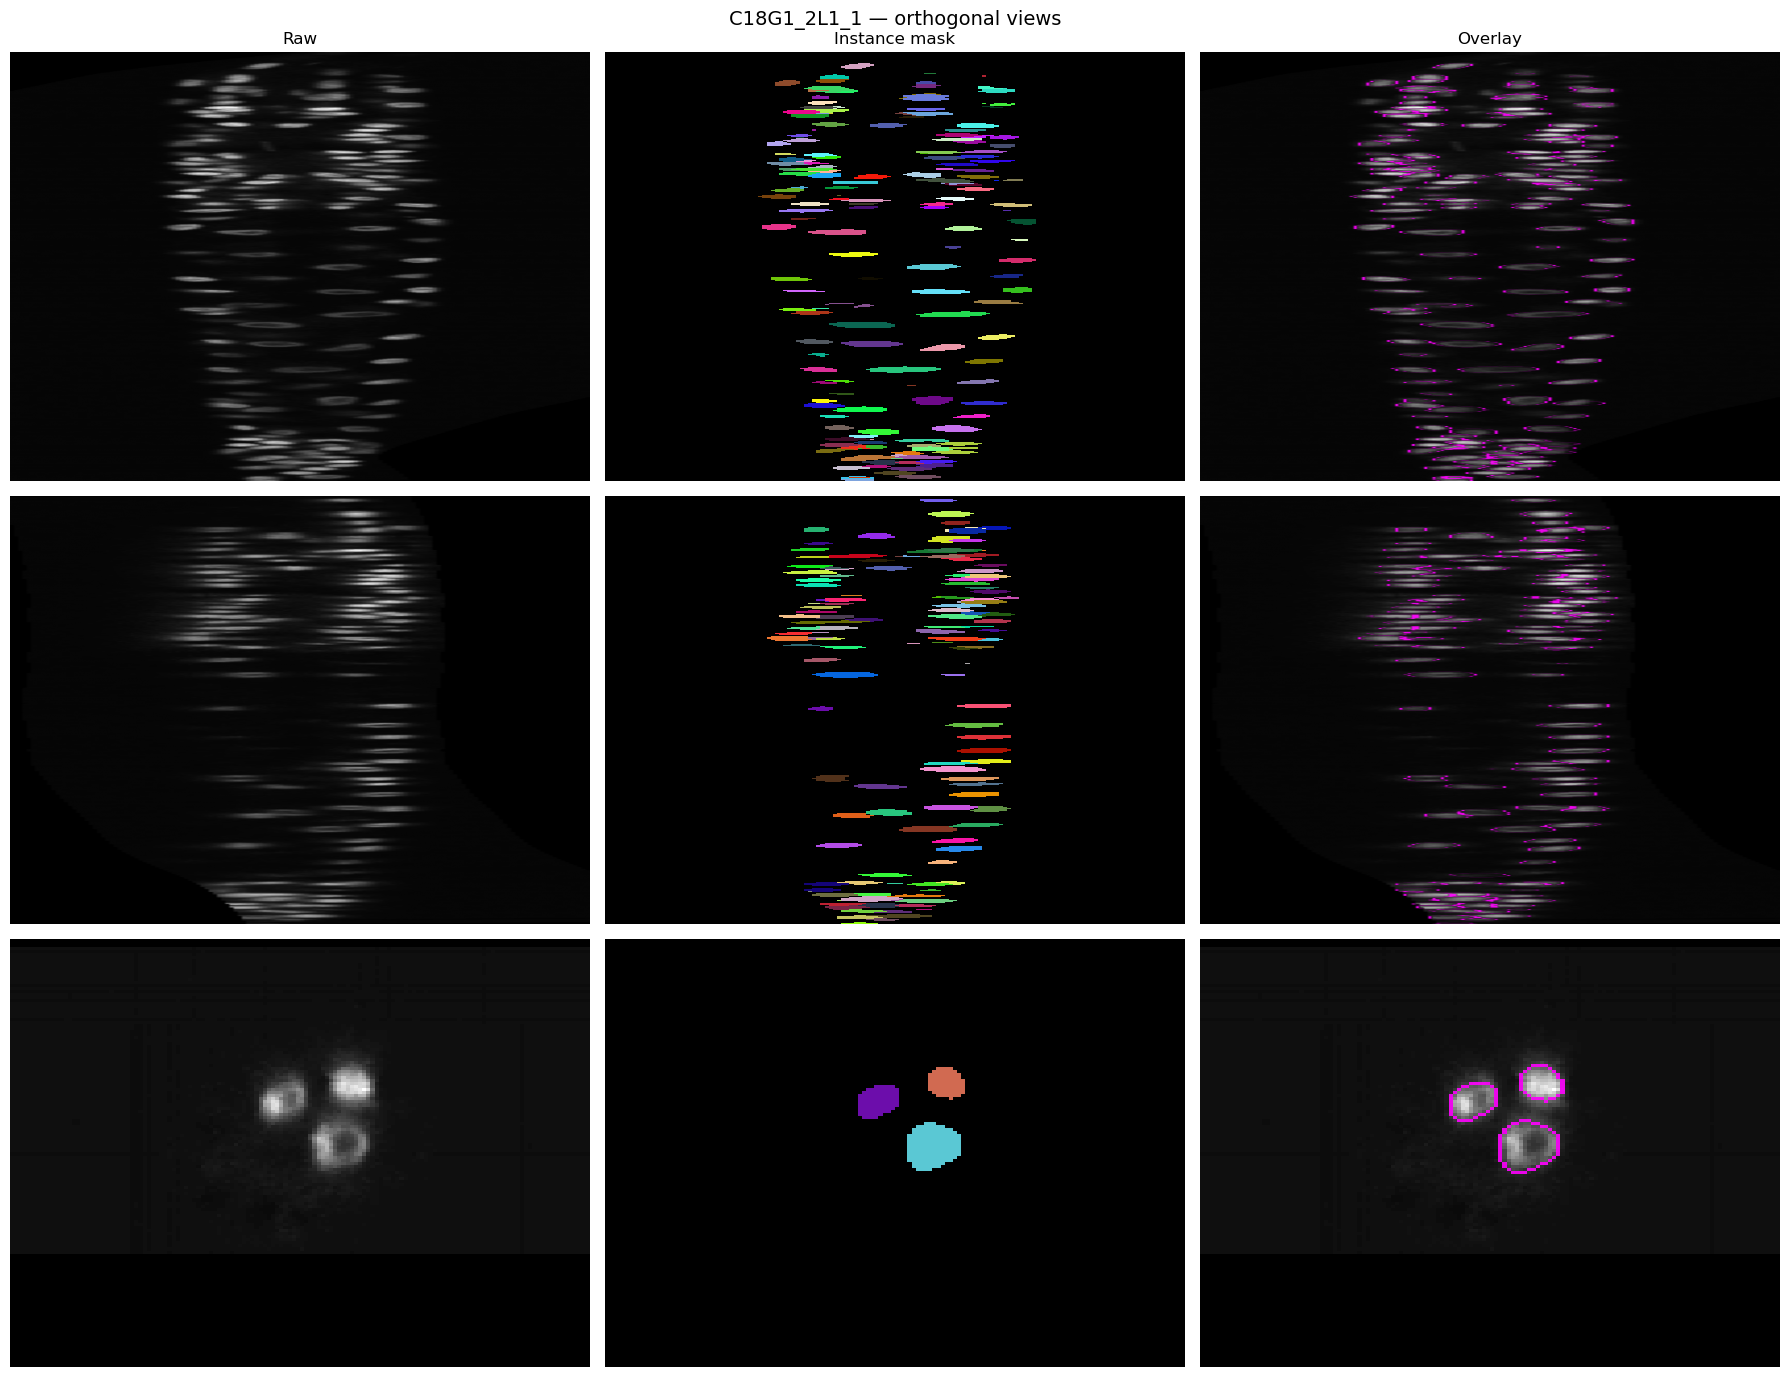

In [5]:
# Random colormap for instances
def make_instance_cmap(n):
    colors = np.random.default_rng(42).random((max(n + 1, 2), 3))
    colors[0] = [0, 0, 0]
    return ListedColormap(colors)

# Orthogonal slices through the volume center
mid_y, mid_x, mid_z = ny // 2, nx // 2, nz // 2

slices = {
    "XZ (axial)": (img[mid_y, :, :].T, mask[mid_y, :, :].T),
    "YZ (sagittal)": (img[:, mid_x, :].T, mask[:, mid_x, :].T),
    "XY (coronal)": (img[:, :, mid_z], mask[:, :, mid_z]),
}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for row, (label, (img_sl, mask_sl)) in enumerate(slices.items()):
    n_inst = len(np.unique(mask_sl)) - 1
    cmap = make_instance_cmap(mask_sl.max())
    bnd = find_boundaries(mask_sl, mode="outer")
    
    axes[row, 0].imshow(img_sl, cmap="gray", aspect="auto")
    axes[row, 0].set_ylabel(label, fontsize=12)
    
    axes[row, 1].imshow(mask_sl, cmap=cmap, interpolation="nearest", aspect="auto")
    axes[row, 1].set_title(f"{n_inst} nuclei" if row == 0 else "")
    
    axes[row, 2].imshow(img_sl, cmap="gray", aspect="auto")
    axes[row, 2].imshow(np.ma.masked_where(~bnd, bnd), cmap="spring", alpha=0.9, aspect="auto")

axes[0, 0].set_title("Raw")
axes[0, 1].set_title("Instance mask")
axes[0, 2].set_title("Overlay")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(f"{name} — orthogonal views", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Walk through Z — longitudinal slices along the worm

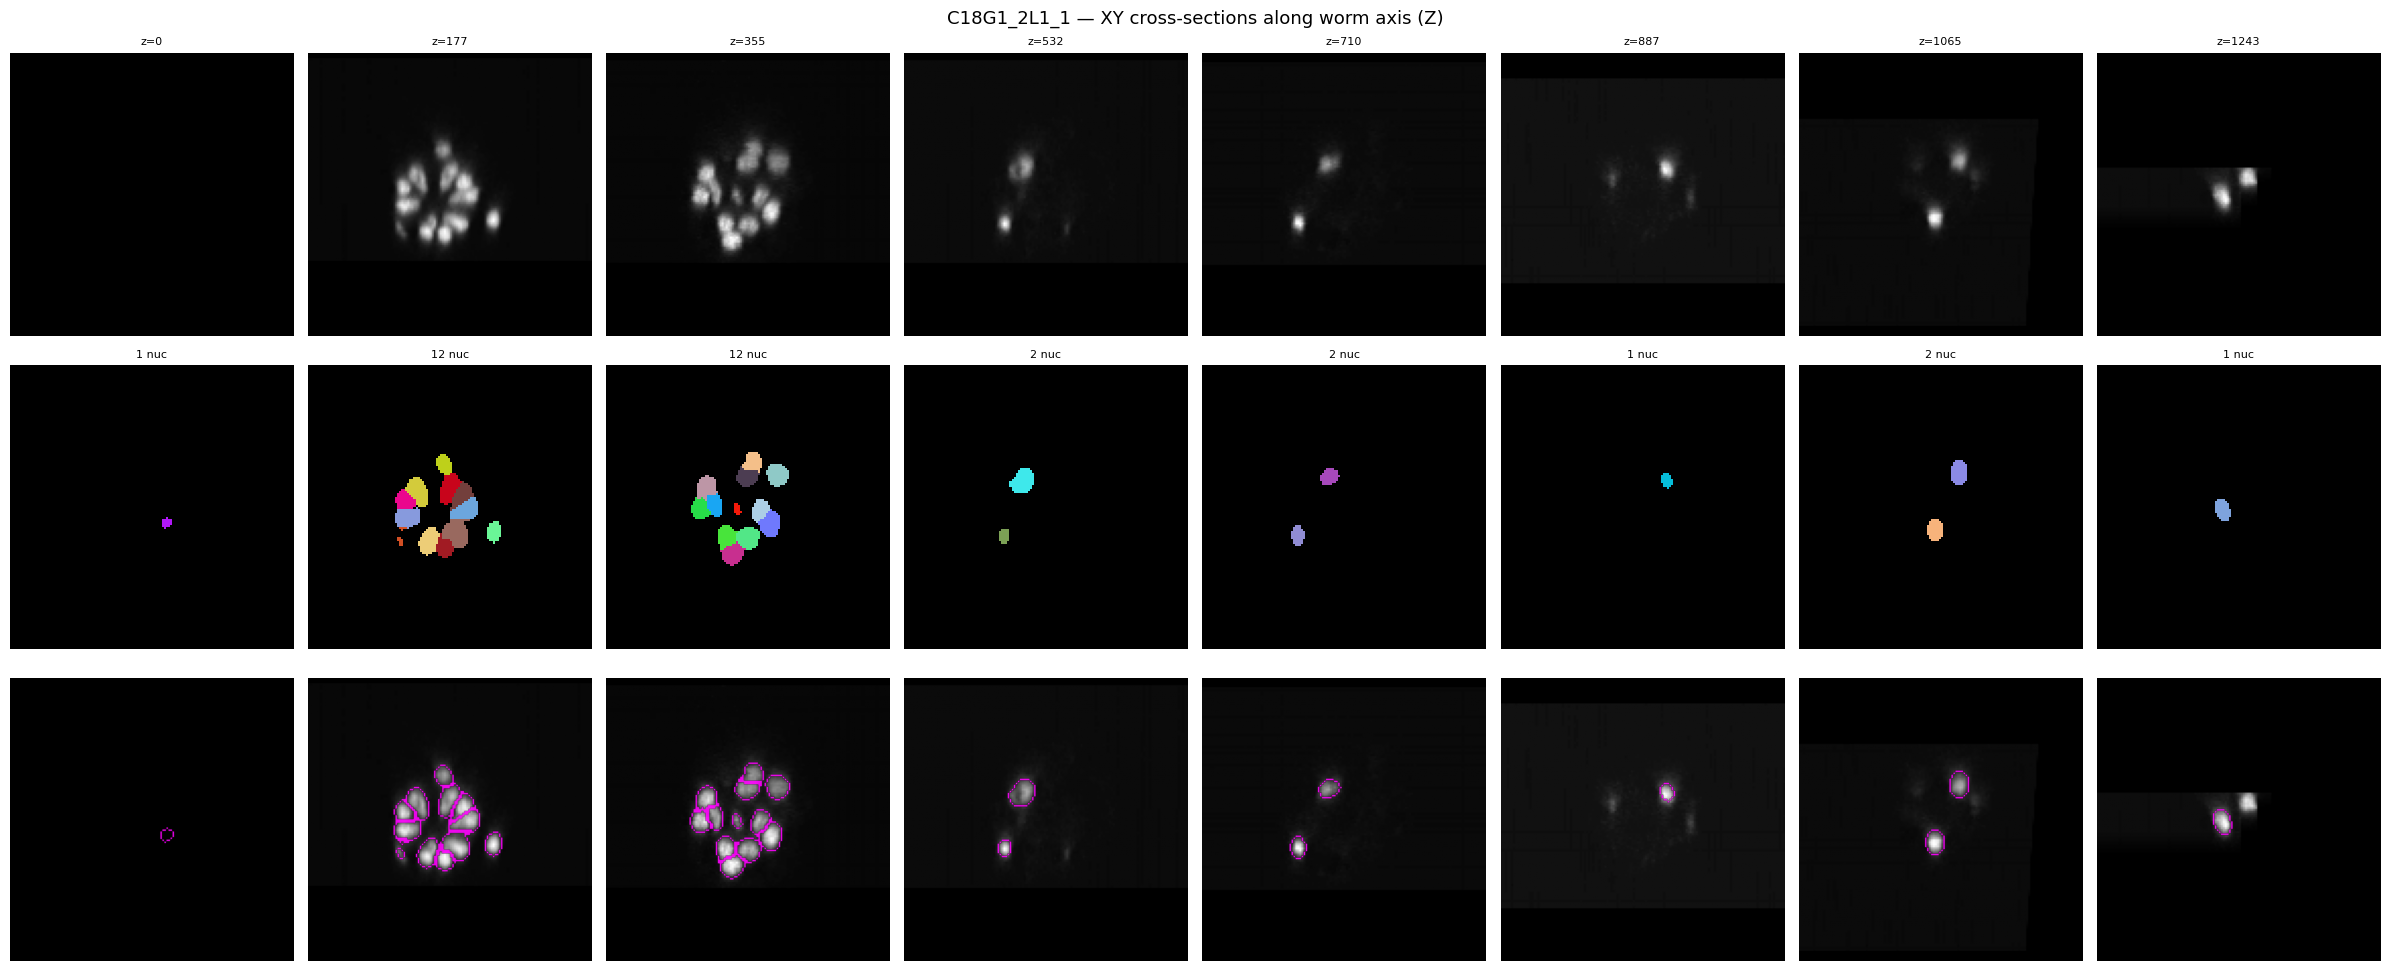

In [6]:
# Show XY slices at evenly spaced Z positions along the worm
n_panels = 8
z_positions = np.linspace(0, nz - 1, n_panels, dtype=int)

fig, axes = plt.subplots(3, n_panels, figsize=(3 * n_panels, 10))

for j, z in enumerate(z_positions):
    img_sl = img[:, :, z]
    mask_sl = mask[:, :, z]
    n_inst = len(np.unique(mask_sl)) - 1
    cmap = make_instance_cmap(mask_sl.max())
    bnd = find_boundaries(mask_sl, mode="outer")
    
    axes[0, j].imshow(img_sl, cmap="gray")
    axes[0, j].set_title(f"z={z}", fontsize=8)
    
    axes[1, j].imshow(mask_sl, cmap=cmap, interpolation="nearest")
    axes[1, j].set_title(f"{n_inst} nuc", fontsize=8)
    
    axes[2, j].imshow(img_sl, cmap="gray")
    axes[2, j].imshow(np.ma.masked_where(~bnd, bnd), cmap="spring", alpha=0.9)

for ax in axes.flat:
    ax.axis("off")

axes[0, 0].set_ylabel("Raw", fontsize=10)
axes[1, 0].set_ylabel("Mask", fontsize=10)
axes[2, 0].set_ylabel("Overlay", fontsize=10)
plt.suptitle(f"{name} — XY cross-sections along worm axis (Z)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Maximum intensity projections

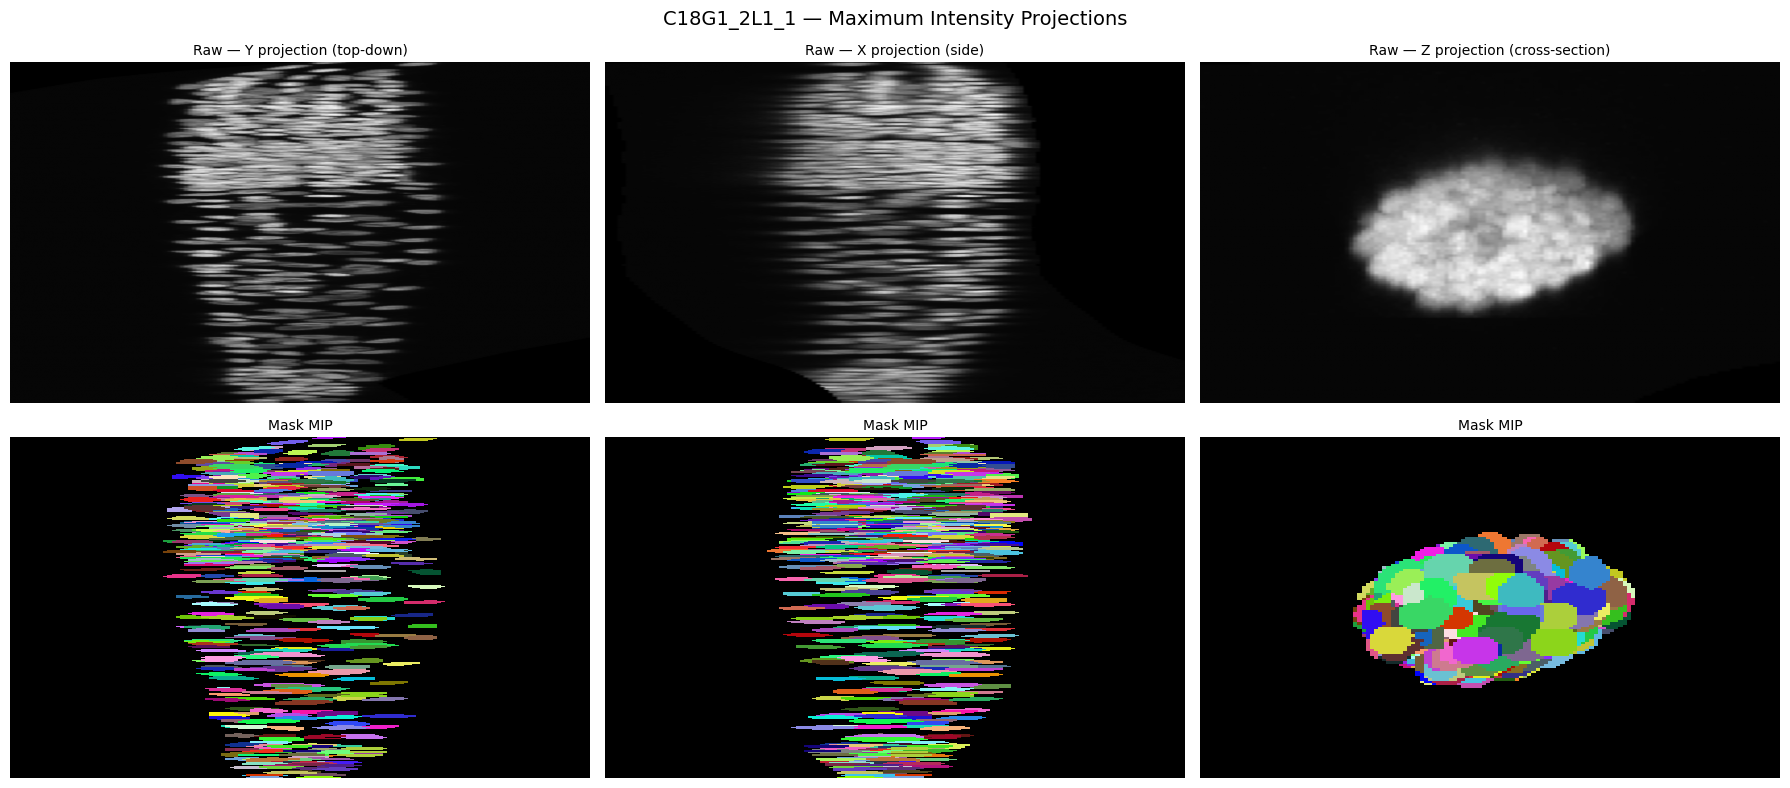

In [7]:
# MIPs along each axis
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

projections = [
    ("Y projection (top-down)", img.max(axis=0).T, mask.max(axis=0).T),
    ("X projection (side)", img.max(axis=1).T, mask.max(axis=1).T),
    ("Z projection (cross-section)", img.max(axis=2), mask.max(axis=2)),
]

for j, (title, img_mip, mask_mip) in enumerate(projections):
    axes[0, j].imshow(img_mip, cmap="gray", aspect="auto")
    axes[0, j].set_title(f"Raw — {title}", fontsize=10)
    axes[0, j].axis("off")
    
    cmap = make_instance_cmap(mask_mip.max())
    axes[1, j].imshow(mask_mip, cmap=cmap, interpolation="nearest", aspect="auto")
    axes[1, j].set_title(f"Mask MIP", fontsize=10)
    axes[1, j].axis("off")

plt.suptitle(f"{name} — Maximum Intensity Projections", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Nucleus size statistics

In [8]:
# Compute 3D region properties across all training volumes
all_volumes = []
all_areas = []

for c in catalog:
    props = regionprops(c["mask"])
    areas = np.array([p.area for p in props])
    all_areas.extend(areas)
    all_volumes.append({
        "name": c["name"], "split": c["split"],
        "n_nuclei": len(props),
        "median_area": np.median(areas),
        "mean_area": np.mean(areas),
    })

all_areas = np.array(all_areas)

# Convert voxel area to physical volume
voxel_vol_um3 = 0.116 * 0.116 * 0.122  # µm³ per voxel
phys_volumes = all_areas * voxel_vol_um3

# Equivalent sphere diameter
equiv_diam = (6 * phys_volumes / np.pi) ** (1/3)

print(f"Total nuclei across all volumes: {len(all_areas):,}")
print(f"\nNucleus volume (voxels):")
print(f"  Median: {np.median(all_areas):.0f}")
print(f"  Mean:   {np.mean(all_areas):.0f} ± {np.std(all_areas):.0f}")
print(f"  Range:  [{all_areas.min()}, {all_areas.max()}]")
print(f"\nNucleus volume (µm³):")
print(f"  Median: {np.median(phys_volumes):.1f}")
print(f"  Mean:   {np.mean(phys_volumes):.1f} ± {np.std(phys_volumes):.1f}")
print(f"\nEquivalent sphere diameter (µm):")
print(f"  Median: {np.median(equiv_diam):.2f}")
print(f"  Mean:   {np.mean(equiv_diam):.2f} ± {np.std(equiv_diam):.2f}")
print(f"  Range:  [{equiv_diam.min():.2f}, {equiv_diam.max():.2f}]")

Total nuclei across all volumes: 15,148

Nucleus volume (voxels):
  Median: 958
  Mean:   1058 ± 473
  Range:  [1.0, 4373.0]

Nucleus volume (µm³):
  Median: 1.6
  Mean:   1.7 ± 0.8

Equivalent sphere diameter (µm):
  Median: 1.44
  Mean:   1.46 ± 0.21
  Range:  [0.15, 2.39]


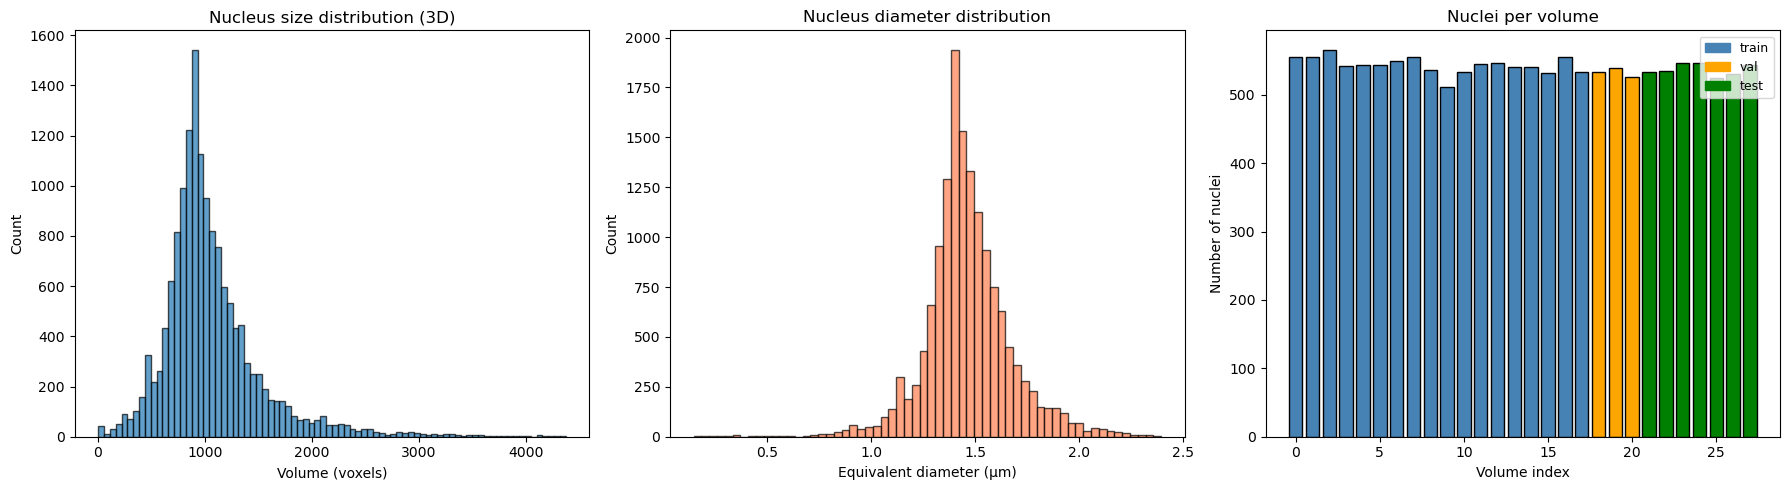

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(all_areas, bins=80, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Volume (voxels)")
axes[0].set_ylabel("Count")
axes[0].set_title("Nucleus size distribution (3D)")

axes[1].hist(equiv_diam, bins=60, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("Equivalent diameter (µm)")
axes[1].set_ylabel("Count")
axes[1].set_title("Nucleus diameter distribution")

nuclei_per_vol = [c["n_nuclei"] for c in catalog]
splits = [c["split"] for c in catalog]
colors = {"train": "steelblue", "val": "orange", "test": "green"}
bar_colors = [colors[s] for s in splits]
axes[2].bar(range(len(nuclei_per_vol)), nuclei_per_vol, color=bar_colors, edgecolor="black")
axes[2].set_xlabel("Volume index")
axes[2].set_ylabel("Number of nuclei")
axes[2].set_title("Nuclei per volume")
# Legend
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(color=c, label=s) for s, c in colors.items()], fontsize=9)

plt.tight_layout()
plt.show()

## 6. Compare across volumes

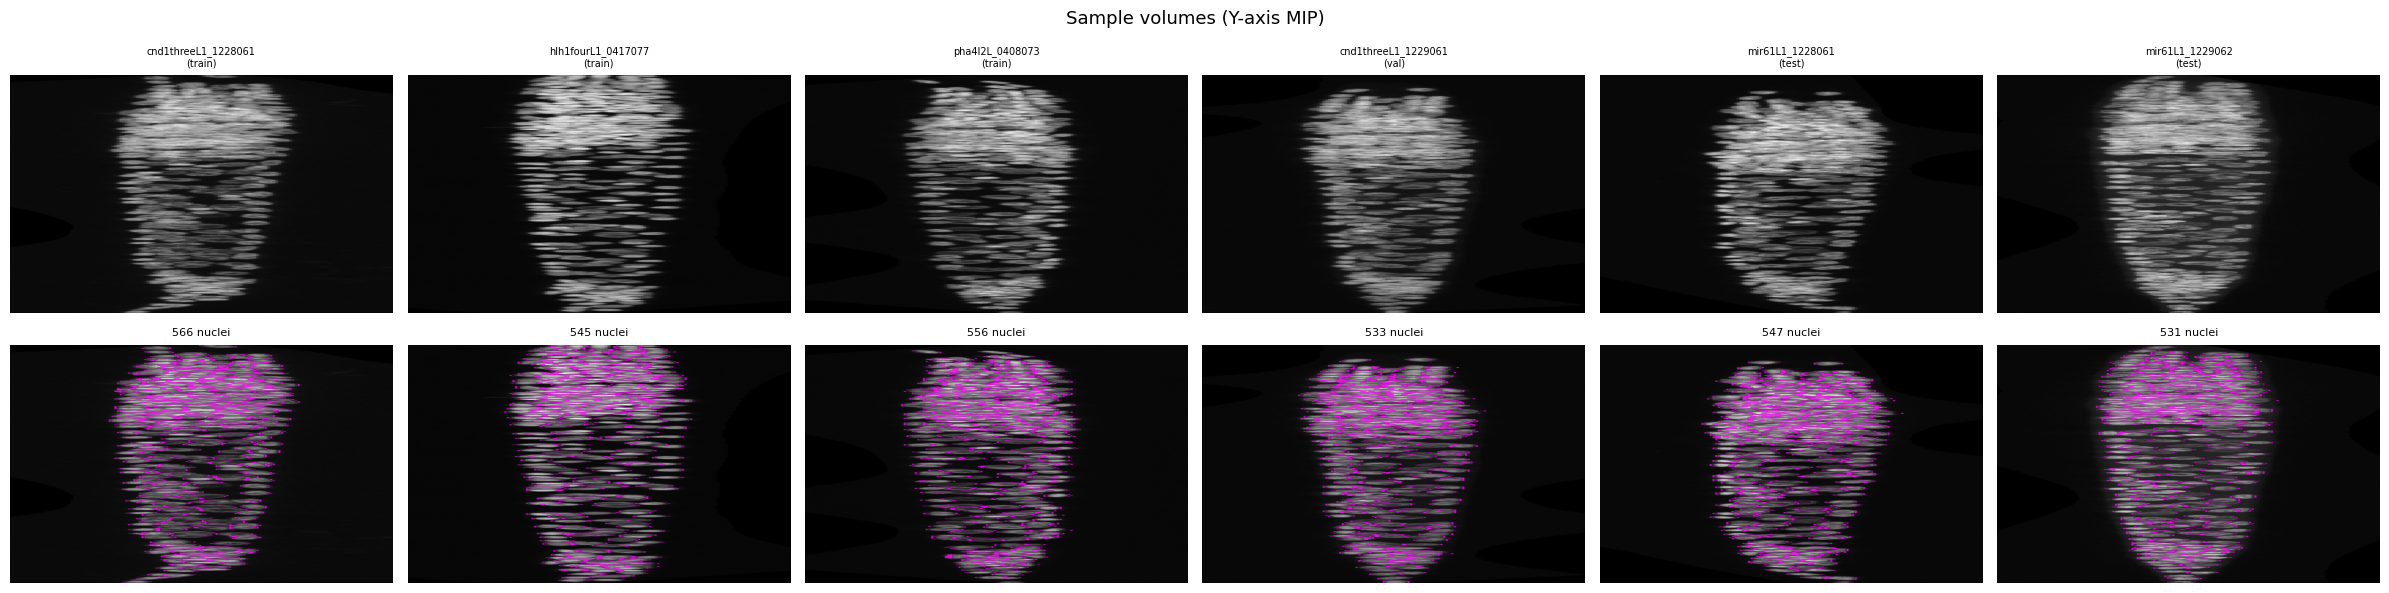

In [10]:
# Show MIP of raw + overlay for 6 random volumes
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(catalog), size=min(6, len(catalog)), replace=False)
sample_idx.sort()

fig, axes = plt.subplots(2, len(sample_idx), figsize=(4 * len(sample_idx), 6))

for j, idx in enumerate(sample_idx):
    c = catalog[idx]
    # Y-axis MIP (top-down longitudinal view)
    img_mip = c["img"].max(axis=0).T  # shape: (Z, X)
    mask_mip = c["mask"].max(axis=0).T
    
    axes[0, j].imshow(img_mip, cmap="gray", aspect="auto")
    axes[0, j].set_title(f"{c['name'][:20]}\n({c['split']})", fontsize=7)
    axes[0, j].axis("off")
    
    bnd = find_boundaries(mask_mip, mode="outer")
    axes[1, j].imshow(img_mip, cmap="gray", aspect="auto")
    axes[1, j].imshow(np.ma.masked_where(~bnd, bnd), cmap="spring", alpha=0.8, aspect="auto")
    axes[1, j].set_title(f"{c['n_nuclei']} nuclei", fontsize=8)
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Raw MIP", fontsize=10)
axes[1, 0].set_ylabel("+ boundaries", fontsize=10)
plt.suptitle("Sample volumes (Y-axis MIP)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Nucleus spatial distribution

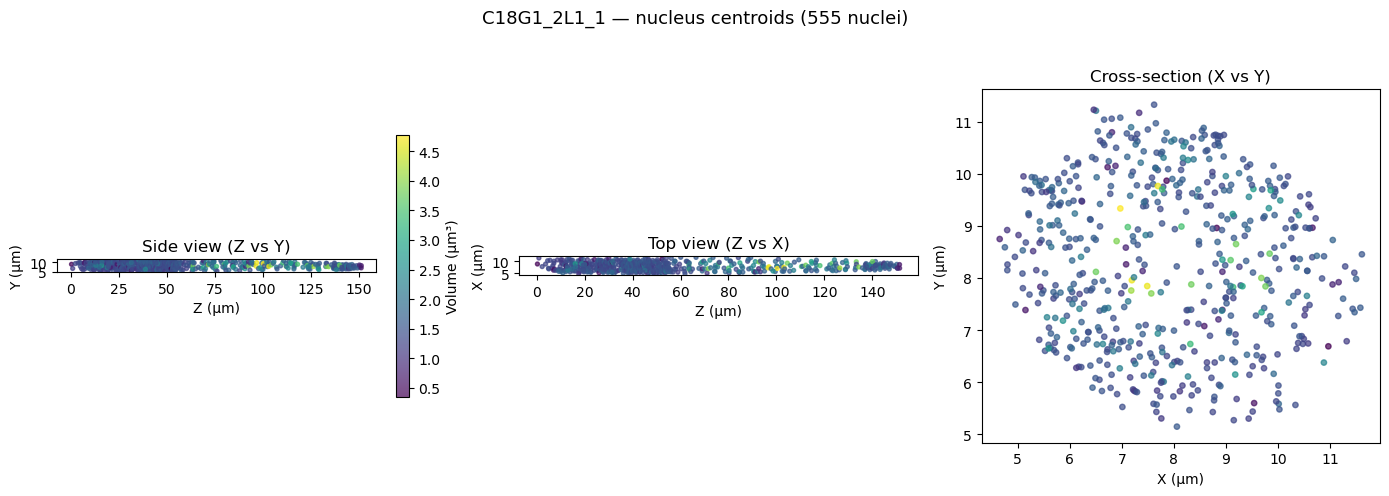

In [11]:
# 3D scatter of nucleus centroids for one volume
props = regionprops(mask)
centroids = np.array([p.centroid for p in props])  # (Y, X, Z)
volumes = np.array([p.area for p in props])

fig = plt.figure(figsize=(14, 5))

# 2D scatter: Z vs Y (side view)
ax1 = fig.add_subplot(131)
sc1 = ax1.scatter(centroids[:, 2] * 0.122, centroids[:, 0] * 0.116,
                  c=volumes * voxel_vol_um3, cmap="viridis", s=8, alpha=0.7)
ax1.set_xlabel("Z (µm)")
ax1.set_ylabel("Y (µm)")
ax1.set_title("Side view (Z vs Y)")
ax1.set_aspect("equal")
plt.colorbar(sc1, ax=ax1, label="Volume (µm³)", shrink=0.6)

# 2D scatter: Z vs X (top view)
ax2 = fig.add_subplot(132)
ax2.scatter(centroids[:, 2] * 0.122, centroids[:, 1] * 0.116,
            c=volumes * voxel_vol_um3, cmap="viridis", s=8, alpha=0.7)
ax2.set_xlabel("Z (µm)")
ax2.set_ylabel("X (µm)")
ax2.set_title("Top view (Z vs X)")
ax2.set_aspect("equal")

# Cross-section: Y vs X
ax3 = fig.add_subplot(133)
ax3.scatter(centroids[:, 1] * 0.116, centroids[:, 0] * 0.116,
            c=volumes * voxel_vol_um3, cmap="viridis", s=15, alpha=0.7)
ax3.set_xlabel("X (µm)")
ax3.set_ylabel("Y (µm)")
ax3.set_title("Cross-section (X vs Y)")
ax3.set_aspect("equal")

plt.suptitle(f"{name} — nucleus centroids ({len(props)} nuclei)", fontsize=13)
plt.tight_layout()
plt.show()

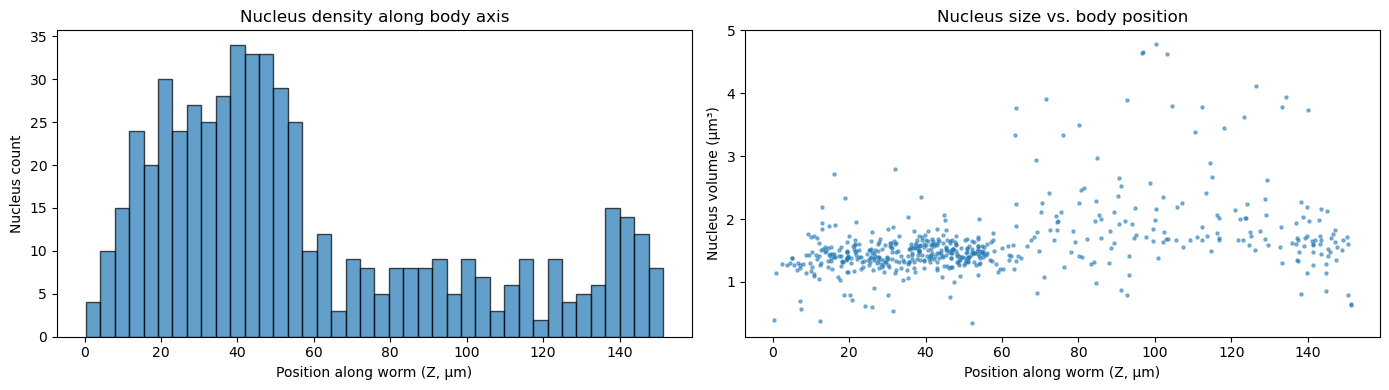

In [12]:
# Nucleus density along the worm body axis (Z)
z_coords = centroids[:, 2] * 0.122  # µm

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(z_coords, bins=40, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Position along worm (Z, µm)")
axes[0].set_ylabel("Nucleus count")
axes[0].set_title("Nucleus density along body axis")

# Nucleus size vs position
axes[1].scatter(z_coords, volumes * voxel_vol_um3, s=5, alpha=0.5)
axes[1].set_xlabel("Position along worm (Z, µm)")
axes[1].set_ylabel("Nucleus volume (µm³)")
axes[1].set_title("Nucleus size vs. body position")

plt.tight_layout()
plt.show()

## Summary

This dataset provides high-quality, densely annotated 3D nuclear segmentation ground truth.
While it's *C. elegans* (not zebrafish), the segmentation task is very similar — instance
segmentation of fluorescent nuclei in 3D confocal volumes. This dataset could be useful for:

- **Benchmarking** our watershed and U-Net approaches
- **Pre-training** a segmentation model before fine-tuning on zebrafish data
- **Validating** our training pipeline end-to-end on a dataset with known-good labels